# Fine tuning 2

Reentrenamiento de los modelos U-Net, DeepLabV3+ y SegFormer con el Dataset CityScapes.

In [1]:
import os
import time
import gc
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import Cityscapes

import albumentations as A                      

import cv2
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F
from tqdm.notebook import tqdm
from torch.utils.tensorboard import SummaryWriter
from torchmetrics.segmentation import MeanIoU
from torchmetrics import JaccardIndex

import segmentation_models_pytorch as smp
from transformers import SegformerForSemanticSegmentation, SegformerConfig

from torch.amp import autocast, GradScaler

from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

In [ ]:
CONFIG = {
    "epochs": 80,
    "batch": 4,
    "num_clases": 19,
    "seed": 42,
    "data": '../data/cityscapes',
    "checkpoint_dir": "../checkpoints/cityscapes/",
    "logs_dir": "../logs/cityscapes/",
    "mem_dir": "../memoria/benchmark2/"
}

HIPER_UN = {
    "lr": 1e-4,                                     # Ratio de aprendizaje.
    "weight_decay": 1e-4,                           # Anti-overfitting
}

HIPER_DL = {
    "lr": 1e-4,                                     # Ratio de aprendizaje.
    "weight_decay": 1e-4,                           # Anti-overfitting
}

HIPER_SF = {
    "lr": 1e-4,                                     # Ratio de aprendizaje.
    "weight_decay": 1e-4,                           # Anti-overfitting
}

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]



torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])


# Crear carpetas necesarias
#os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
#os.makedirs(CONFIG["logs_dir"], exist_ok=True)
#os.makedirs(CONFIG["mem_dir"], exist_ok=True)

In [3]:
#### GPU Info ####
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Usando: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [6]:
CROP_SIZE = 512   #  512, 768 o 1024

transform_train = A.Compose([
    # Escalado aleatorio sobre la imagen original (multi-scale training)
    A.RandomScale(scale_limit=(-0.5, 1.0), p=1.0,
                  interpolation=cv2.INTER_LINEAR),
    
    # Padding por si el escalado dejó algún lado menor que CROP_SIZE
    A.PadIfNeeded(
        min_height=CROP_SIZE,
        min_width=CROP_SIZE,
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        fill_mask=255
    ),
    
    # Recorte cuadrado aleatorio (NO panorámico, para que entre en VRAM)
    A.RandomCrop(CROP_SIZE, CROP_SIZE),
    
    # Augmentations
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.0, p=0.5),
    
    # Normalización
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])


transform_val = A.Compose([
    A.Resize(512, 1024,
             interpolation=cv2.INTER_LINEAR,
             mask_interpolation=cv2.INTER_NEAREST),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

In [5]:
"""
names:
  0: road
  1: sidewalk
  2: building
  3: wall
  4: fence
  5: pole
  6: traffic light
  7: traffic sign
  8: vegetation
  9: terrain
  10: sky
  11: person
  12: rider
  13: car
  14: truck
  15: bus
  16: train
  17: motorcycle
  18: bicycle
"""

"""
label_mapping:
  -1: ignore_label
  0: ignore_label
  1: ignore_label
  2: ignore_label
  3: ignore_label
  4: ignore_label
  5: ignore_label
  6: ignore_label
  7: 0
  8: 1
  9: ignore_label
  10: ignore_label
  11: 2
  12: 3
  13: 4
  14: ignore_label
  15: ignore_label
  16: ignore_label
  17: 5
  18: ignore_label
  19: 6
  20: 7
  21: 8
  22: 9
  23: 10
  24: 11
  25: 12
  26: 13
  27: 14
  28: 15
  29: ignore_label
  30: ignore_label
  31: 16
  32: 17
  33: 18
"""

'\nlabel_mapping:\n  -1: ignore_label\n  0: ignore_label\n  1: ignore_label\n  2: ignore_label\n  3: ignore_label\n  4: ignore_label\n  5: ignore_label\n  6: ignore_label\n  7: 0\n  8: 1\n  9: ignore_label\n  10: ignore_label\n  11: 2\n  12: 3\n  13: 4\n  14: ignore_label\n  15: ignore_label\n  16: ignore_label\n  17: 5\n  18: ignore_label\n  19: 6\n  20: 7\n  21: 8\n  22: 9\n  23: 10\n  24: 11\n  25: 12\n  26: 13\n  27: 14\n  28: 15\n  29: ignore_label\n  30: ignore_label\n  31: 16\n  32: 17\n  33: 18\n'

In [4]:
ID_TO_TRAINID = {
    -1: 255,   # license plate
    0: 255,  # unlabeled
    1: 255,  # ego vehicle
    2: 255,  # rectification border
    3: 255,  # out of roi
    4: 255,  # static
    5: 255,  # dynamic
    6: 255,  # ground
    7: 0,    # road
    8: 1,    # sidewalk
    9: 255,  # parking
    10: 255,  # rail track
    11: 2,    # building
    12: 3,    # wall
    13: 4,    # fence
    14: 255,  # guard rail
    15: 255,  # bridge
    16: 255,  # tunnel
    17: 5,    # pole
    18: 255,  # polegroup
    19: 6,    # traffic light
    20: 7,    # traffic sign
    21: 8,    # vegetation
    22: 9,    # terrain
    23: 10,   # sky
    24: 11,   # person
    25: 12,   # rider
    26: 13,   # car
    27: 14,   # truck
    28: 15,   # bus
    29: 255,  # caravan
    30: 255,  # trailer
    31: 16,   # train
    32: 17,   # motorcycle
    33: 18    # bicycle
}

In [5]:
LUT = np.full(34, 255, dtype=np.uint8)
for id_original, train_id in ID_TO_TRAINID.items():
    if id_original >= 0:
        LUT[id_original] = train_id


def convert_mask_id(mask):
    """Convierte máscara con IDs originales de Cityscapes a trainIds."""
    mask = np.asarray(mask, dtype=np.int32)
    
    mask = np.clip(mask, 0, 33)  # protege contra valores inesperados
    return LUT[mask]

In [ ]:
class Dataset_Cityscapes(Dataset):

    def __init__(self, conjunto="train", transform=None):
        self.dataset = Cityscapes(
            root=CONFIG["data"],
            split=conjunto,
            mode="fine",
            target_type="semantic"
        )
        self.transform=transform

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, indice:int):
        image, mask = self.dataset[indice]

        image = np.array(image)
        mask = np.array(mask)

        mask = convert_mask_id(mask)
        mask = mask.astype(np.uint8)

        if self.transform:
            t = self.transform(image=image, mask=mask)
            image = t["image"]
            mask = t["mask"].long()
        return image, mask
        

In [ ]:
train_data = Dataset_Cityscapes(conjunto="train", transform=transform_train)
val_data = Dataset_Cityscapes(conjunto="val", transform=transform_val)


In [11]:
img, mascara = train_data[0]
img.shape[-2:]

torch.Size([512, 512])

In [12]:
train_loader = DataLoader(
    train_data,
    batch_size=CONFIG["batch"],
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=CONFIG["batch"],
    shuffle=False,
    num_workers=0,
    pin_memory=True
)



In [13]:
print(f"N° imágenes de entrenamiento: {len(train_data)} imágenes | {len(train_loader)} batches")
print(f"N° imágene de validación: {len(val_data)} imágenes | {len(val_loader)} batches")

N° imágenes de entrenamiento: 2975 imágenes | 744 batches
N° imágene de validación: 500 imágenes | 125 batches


In [ ]:
r = set()
for i in ID_TO_TRAINID.values():
    r.add(i)

print(f"El dataset CityScapes tiene {len(r)} clases distintas.\n19 objetos y el fondo")
print(r)

El dataset CityScape tiene 20 clases distintas.
19 objetos y el fondo
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 255}


In [15]:
COLOR_DIC = {
    0:[128,0,0],
    1:[0,128,0],
    2:[128,128,0],
    3:[0,0,128],
    4:[128,0,128],
    5:[0,128,128],
    6:[128,128,128],
    7:[64,0,0],
    8:[0,200,0],
    9:[192,0,0],
    10:[64,128,0],
    11:[192,128,0],
    12:[64,0,128],
    13:[192,0,128],
    14:[64,128,128],
    15:[192,128,128],
    16:[0,64,0],
    17:[128,64,0],
    18:[0,192,0],
    255: [0,0,0]
}

In [16]:
def colorear_mascara(mask):
    mask_color = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for k, v in COLOR_DIC.items():
        mask_color[mask == k] = v
    return mask_color

In [17]:
def desnormalizar(tensor):
    mean = torch.tensor(MEAN).view(3,1,1)
    std = torch.tensor(STD).view(3,1,1)
    return (tensor*std+mean).clamp(0,1)

In [ ]:
def visualizar_ejemplos(loader, n=4):
    images, masks = next(iter(loader))
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))

    for i in range(n):
        img = desnormalizar(images[i]).permute(1,2,0).numpy()
        axes[0,i].imshow(img)
        axes[0,i].set_title("Imagen")
        axes[0,i].axis("off")

        axes[1,i].imshow(colorear_mascara(masks[i].numpy()))
        axes[1,i].set_title("Máscara")
        axes[1,i].axis("off")

    plt.suptitle("Ejemplos CityScapes", fontsize=14)
    plt.tight_layout()
    plt.show()

Shape imágenes:  torch.Size([4, 3, 512, 512])
Shape máscaras:  torch.Size([4, 512, 512])
Clases únicas:   tensor([  0,   1,   2,   5,   6,   7,   8,   9,  10,  11,  13, 255])


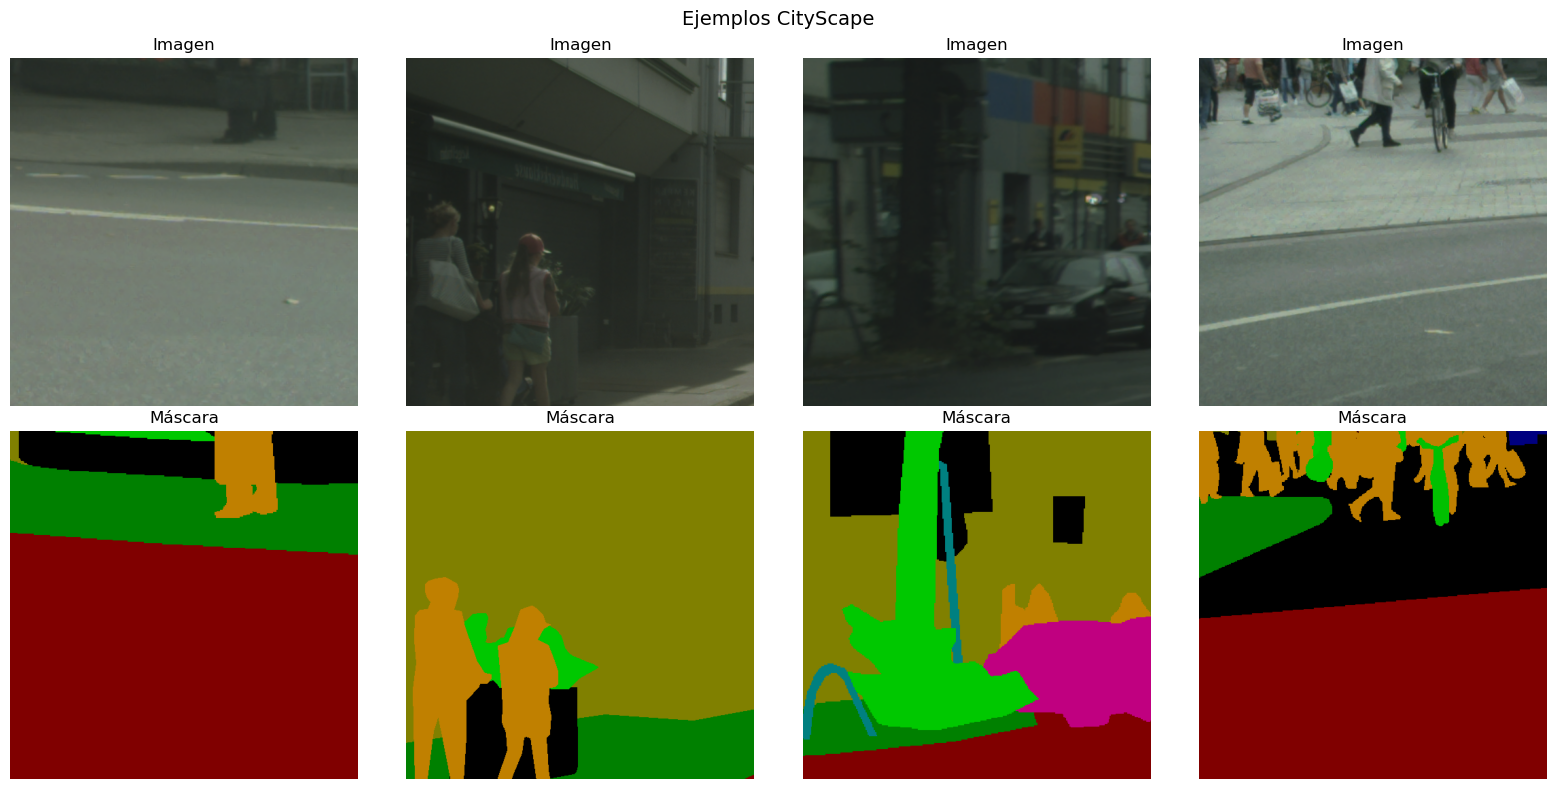

In [19]:
# Verificar shapes
images, masks = next(iter(train_loader))
print(f"Shape imágenes:  {images.shape}")
print(f"Shape máscaras:  {masks.shape}")
print(f"Clases únicas:   {masks.unique()}")

# Visualizar
visualizar_ejemplos(train_loader)

## Definir modelos.

In [20]:
# ── U-Net ──────────────────────────────────────
unet = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=CONFIG["num_clases"]
)

def forward_unet(model, images):
    out = model(images)
    if out.shape[-2:] != images.shape[-2:]:
        out = F.interpolate(out, size=images.shape[-2:], 
                           mode="bilinear", align_corners=False)
    return out

print(f"** U-Net -> N° parámetros: {sum(p.numel() for p in unet.parameters())/1e6:.1f}M")
print("\n** Modelo U-Net cargado")

** U-Net -> N° parámetros: 32.5M

** Modelo U-Net cargado


In [21]:
# ── DeepLabV3+ ──────────────────────────────────
deeplabv3plus = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=CONFIG["num_clases"]
)

def forward_deeplabv3plus(model, images):
    out = model(images)
    if out.shape[-2:] != images.shape[-2:]:
        out = F.interpolate(out, size=images.shape[-2:],
                           mode="bilinear", align_corners=False)
    return out

print(f"\n** DeepLabV3Plus -> N° parámetros: {sum(p.numel() for p in deeplabv3plus.parameters())/1e6:.1f}M")
print("\n** Modelo DeepLabV3Plus cargado")


** DeepLabV3Plus -> N° parámetros: 26.7M

** Modelo DeepLabV3Plus cargado


In [22]:
# ── SegFormer ──────────────────────────────────
segformer = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b2",
    num_labels=CONFIG["num_clases"],
    ignore_mismatched_sizes=True
)

def forward_segformer(model, images):
    outputs = model(pixel_values=images)
    return F.interpolate(
        outputs.logits,
        size=images.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

print(f"\n\n\n** SegFormer -> N° parámetros: {sum(p.numel() for p in segformer.parameters())/1e6:.1f}M")
print("\n** Modelo SegFormer cargado")

[transformers] You passed `num_labels=19` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading fr




** SegFormer -> N° parámetros: 27.4M

** Modelo SegFormer cargado


### Definición función de pérdida

In [23]:
class perdidaDiceCE(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = smp.losses.DiceLoss(
            mode="multiclass",
            ignore_index=255
        )
        self.ce = nn.CrossEntropyLoss(ignore_index=255)

    def forward(self, pred, obj):
        return 0.5 * self.dice(pred, obj) + 0.5 * self.ce(pred, obj)

loss_fn = perdidaDiceCE()
print("-> Función de pérdida definida")

-> Función de pérdida definida


In [ ]:
def entrenar_modelo(modelo, nombre, forward_fn, hiper):
    
    ############################
    # Reset de semilla
    torch.manual_seed(CONFIG["seed"])
    np.random.seed(CONFIG["seed"])
    ############################

    modelo = modelo.to(device)
    
    writer  = SummaryWriter(log_dir=f"../logs/cityscapes/{nombre}")

    miou_fn = JaccardIndex(

        task="multiclass",
        num_classes=CONFIG["num_clases"],
        ignore_index=255,
        average="macro"

    ).to(device)
    
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, modelo.parameters()),
        lr=hiper["lr"],
        weight_decay=hiper["weight_decay"]
    )
    """ 
    # Actualización de la tasa de aprendizaje.##############
    """
    scheduler_step_per_iter=False
    if (nombre == "unet"):
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=CONFIG["epochs"], eta_min=1e-6
        )
        scheduler_step_per_iter = False

    elif(nombre == "deeplabv3plus"):
        scheduler = torch.optim.lr_scheduler.PolynomialLR(
            optimizer,
            total_iters=CONFIG["epochs"] * len(train_loader),
            power=0.9
        )
        scheduler_step_per_iter = True

    else:
        scheduler = torch.optim.lr_scheduler.PolynomialLR(
            optimizer,
            total_iters=CONFIG["epochs"] * len(train_loader),
            power=1.0
        )
        scheduler_step_per_iter = True
    
    
    
    """ 
    ########################################################
    """

    scaler = GradScaler("cuda")
    
    historial = {
        "loss_train": [],
        "miou_val":   []
    }

    tiempo_entrenamiento = 0.0
    mejor_miou = 0.0
    
    for epoch in range(CONFIG["epochs"]):

        # Aquí empieza el entrenamiento de cada epoch
        inicio_epoch = time.time()
        # -- Train ---------------------------
        modelo.train()
        loss_total = 0

        pbar = tqdm(
            train_loader,
            desc=f"[{nombre}] Epoch {epoch+1}/{CONFIG['epochs']}",
            leave=False
        )
        
        for images, masks in pbar:
            images = images.to(device, non_blocking=True)
            masks = masks.long().to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast("cuda"):
                preds = forward_fn(modelo, images)
                loss = loss_fn(preds, masks)


            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            if scheduler_step_per_iter:
                scheduler.step()

            loss_total += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")


        loss_media = loss_total / len(train_loader)

        

        # -- Validación ---------------------------
        modelo.eval()
        miou_fn.reset()

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks  = masks.long().to(device)
                preds  = forward_fn(modelo, images).argmax(dim=1)
                miou_fn.update(preds, masks)


        miou_val = miou_fn.compute().item()   
            

        tiempo_epoch = (time.time() - inicio_epoch)/60 # tiempo en min del entrenamiento de cada epochs.
        # -- Sumar tiempo epoch ---------------------------
        tiempo_entrenamiento += tiempo_epoch    # Sumo tiempo de epoch.

        # -- Guardar historial ---------------------------
        historial["loss_train"].append(loss_media)
        historial["miou_val"].append(miou_val)
        
        # -- TensorBoard ---------------------------
        writer.add_scalar("Loss/train", loss_media, epoch)
        writer.add_scalar("mIoU/val", miou_val, epoch)
        writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoch)
        writer.add_scalar("Tiempo/epoch", tiempo_epoch, epoch)

        print(f"[{nombre}] Epoch {epoch+1:02d} | Loss: {loss_media:.4f} | mIoU: {miou_val*100:.2f}% | Tiempo: {tiempo_epoch:.4f} min")

        # -- Guardar mejor modelo ---------------------------
        if miou_val > mejor_miou:
            mejor_miou = miou_val
            torch.save({
                "epoch":          epoch,
                "modelo":         modelo.state_dict(),
                "optimizer":      optimizer.state_dict(),
                "scheduler":      scheduler.state_dict(),
                "mejor_miou":     mejor_miou,
                "historial":      historial
            },
            f"{CONFIG['checkpoint_dir']}{nombre}_b2_checkpoint.pth"
            )
            print(f"  -- Guardado modelo {nombre} con mIoU = {mejor_miou*100:.2f}%")

        if not scheduler_step_per_iter:
            scheduler.step()   # disminuye learning rate.
    
    writer.close()
    
    print(f"\n\n-->>    {nombre} completado | Mejor mIoU: {mejor_miou*100:.2f}% | Tiempo total de entrenamiento: {tiempo_entrenamiento:.2f} min   <<--")
    
    #--- Libero memoria VRAM ------------------
    modelo.cpu()
    del modelo
    del optimizer
    del scheduler
    del miou_fn
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    #--------------------------------
    
    return mejor_miou, historial, tiempo_entrenamiento

In [26]:
# Entrenar U-net
miou_unet, hist_unet, tiempo_en_unet = entrenar_modelo(
    modelo=unet, nombre="unet", forward_fn=forward_unet, hiper=HIPER_UN
)

[unet] Epoch 1/80:   0%|          | 0/744 [00:00<?, ?it/s]

[unet] Epoch 01 | Loss: 0.8451 | mIoU: 30.30% | Tiempo: 5.7317 min
  -- Guardado modelo unet con mIoU = 30.30%


[unet] Epoch 2/80:   0%|          | 0/744 [00:00<?, ?it/s]

[unet] Epoch 02 | Loss: 0.5606 | mIoU: 33.71% | Tiempo: 5.7038 min
  -- Guardado modelo unet con mIoU = 33.71%


[unet] Epoch 3/80:   0%|          | 0/744 [00:00<?, ?it/s]

...

[unet] Epoch 78 | Loss: 0.1785 | mIoU: 68.76% | Tiempo: 5.7402 min


[unet] Epoch 79/80:   0%|          | 0/744 [00:00<?, ?it/s]

[unet] Epoch 79 | Loss: 0.1778 | mIoU: 68.38% | Tiempo: 5.7397 min


[unet] Epoch 80/80:   0%|          | 0/744 [00:00<?, ?it/s]

[unet] Epoch 80 | Loss: 0.1779 | mIoU: 68.96% | Tiempo: 5.7476 min
  -- Guardado modelo unet con mIoU = 68.96%


-->>    unet completado | Mejor mIoU: 68.96% | Tiempo total de entrenamiento: 456.03 min   <<--


In [30]:
#Entrenar DeepLabV3Plus
miou_deeplabv3plus, hist_deeplabv3plus, tiempo_en_deeplab = entrenar_modelo(
    modelo=deeplabv3plus, nombre="deeplabv3plus", forward_fn=forward_deeplabv3plus, hiper=HIPER_DL
)

[deeplabv3plus] Epoch 1/80:   0%|          | 0/744 [00:00<?, ?it/s]

[deeplabv3plus] Epoch 01 | Loss: 0.6470 | mIoU: 34.70% | Tiempo: 5.3917 min
  -- Guardado modelo deeplabv3plus con mIoU = 34.70%


[deeplabv3plus] Epoch 2/80:   0%|          | 0/744 [00:00<?, ?it/s]

[deeplabv3plus] Epoch 02 | Loss: 0.4239 | mIoU: 40.79% | Tiempo: 5.5530 min
  -- Guardado modelo deeplabv3plus con mIoU = 40.79%


[deeplabv3plus] Epoch 3/80:   0%|          | 0/744 [00:00<?, ?it/s]

...

[deeplabv3plus] Epoch 78 | Loss: 0.1590 | mIoU: 71.82% | Tiempo: 5.4899 min
  -- Guardado modelo deeplabv3plus con mIoU = 71.82%


[deeplabv3plus] Epoch 79/80:   0%|          | 0/744 [00:00<?, ?it/s]

[deeplabv3plus] Epoch 79 | Loss: 0.1586 | mIoU: 71.33% | Tiempo: 5.4805 min


[deeplabv3plus] Epoch 80/80:   0%|          | 0/744 [00:00<?, ?it/s]

[deeplabv3plus] Epoch 80 | Loss: 0.1584 | mIoU: 71.77% | Tiempo: 5.4581 min


-->>    deeplabv3plus completado | Mejor mIoU: 71.82% | Tiempo total de entrenamiento: 442.05 min   <<--


In [25]:
# Entrenar SegFormer
miou_segformer, hist_segformer, tiempo_en_segformer = entrenar_modelo(
    modelo=segformer, nombre="segformer", forward_fn=forward_segformer, hiper=HIPER_SF
)

[segformer] Epoch 1/80:   0%|          | 0/744 [00:00<?, ?it/s]

[segformer] Epoch 01 | Loss: 0.4327 | mIoU: 48.71% | Tiempo: 7.0705 min
  -- Guardado modelo segformer con mIoU = 48.71%


[segformer] Epoch 2/80:   0%|          | 0/744 [00:00<?, ?it/s]

[segformer] Epoch 02 | Loss: 0.2972 | mIoU: 55.61% | Tiempo: 7.0961 min
  -- Guardado modelo segformer con mIoU = 55.61%


[segformer] Epoch 3/80:   0%|          | 0/744 [00:00<?, ?it/s]

...

[segformer] Epoch 78 | Loss: 0.1296 | mIoU: 75.64% | Tiempo: 6.9805 min


[segformer] Epoch 79/80:   0%|          | 0/744 [00:00<?, ?it/s]

[segformer] Epoch 79 | Loss: 0.1238 | mIoU: 75.74% | Tiempo: 6.9935 min


[segformer] Epoch 80/80:   0%|          | 0/744 [00:00<?, ?it/s]

[segformer] Epoch 80 | Loss: 0.1258 | mIoU: 75.69% | Tiempo: 6.9752 min


-->>    segformer completado | Mejor mIoU: 75.77% | Tiempo total de entrenamiento: 562.18 min   <<--


# Visualización datos de entrenamiento

In [31]:
"""
ALMACENAR MEJOR mIoU ENTRENAMIENTO.
"""
res_mejor=[]
mejor_unet={"Modelo":"U-Net", 
            "Mejor mIoU(%) entrenamiento":round(miou_unet*100,2), 
            "Tiempo entrenamiento (min)":round(tiempo_en_unet,2)}
res_mejor.append(mejor_unet)

mejor_deeplabv3plus={"Modelo":"DeepLabV3plus",
                     "Mejor mIoU(%) entrenamiento":round(miou_deeplabv3plus*100,2),
                     "Tiempo entrenamiento (min)":round(tiempo_en_deeplab,2)}
res_mejor.append(mejor_deeplabv3plus)

mejor_segformer={"Modelo":"SegFormer",
                 "Mejor mIoU(%) entrenamiento":round(miou_segformer*100,2),
                 "Tiempo entrenamiento (min)":round(tiempo_en_segformer,2)}
res_mejor.append(mejor_segformer)


In [32]:
t = pd.DataFrame(res_mejor)
display(t)

,Modelo,Mejor mIoU(%) entrenamiento,Tiempo entrenamiento (min)
0,U-Net,68.96,456.03
1,DeepLabV3plus,71.82,442.05
2,SegFormer,75.77,562.18


In [33]:
t.to_csv(CONFIG["mem_dir"]+"resultados_b2_entrenamiento.csv")

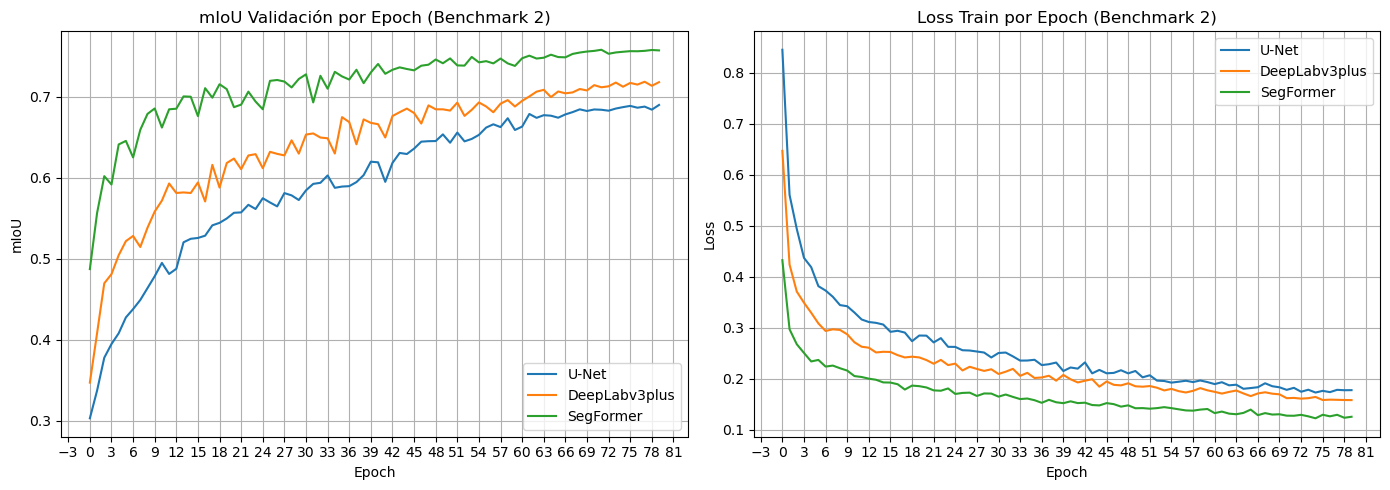

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas mIoU
for nombre, hist in [
    ("U-Net", hist_unet),
    ("DeepLabv3plus", hist_deeplabv3plus),
    ("SegFormer", hist_segformer)
]:
    axes[0].plot(hist["miou_val"], label=nombre)

axes[0].set_title("mIoU Validación por Epoch (Cityscapes)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("mIoU")
axes[0].legend()
axes[0].xaxis.set_major_locator(plt.MultipleLocator(3))
axes[0].grid(True)

# Curvas Loss
for nombre, hist in [
    ("U-Net", hist_unet),
    ("DeepLabv3plus", hist_deeplabv3plus),
    ("SegFormer", hist_segformer)
]:
    axes[1].plot(hist["loss_train"], label=nombre)

axes[1].set_title("Loss Train por Epoch (Cityscapes)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].xaxis.set_major_locator(plt.MultipleLocator(3))
axes[1].grid(True)

plt.tight_layout()
plt.savefig("../memoria/benchmark2/curvas_entrenamiento_b2.png", dpi=150)
plt.show()